In [1]:
# ============================================================
# CELL 0 — GPU sanity check
# ============================================================
import torch
print("CUDA available :", torch.cuda.is_available())
print("GPU count       :", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}         : {torch.cuda.get_device_name(i)}")

CUDA available : True
GPU count       : 2
  GPU 0         : Tesla T4
  GPU 1         : Tesla T4


In [2]:
# ============================================================
# CELL 1 — Install & imports
# ============================================================
import subprocess, sys

subprocess.run(["pip", "install", "timm", "--quiet"], check=True)

import os
if not os.path.exists("/kaggle/working/RepViT"):
    subprocess.run(["git", "clone", "https://github.com/THU-MIG/RepViT.git",
                    "/kaggle/working/RepViT"], check=True)
    subprocess.run(["pip", "install", "-r", "/kaggle/working/RepViT/requirements.txt",
                    "--quiet"], check=True)

sys.path.insert(0, "/kaggle/working/RepViT")

import math, time, urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import pandas as pd

print("All imports OK")
print("RepViT folder:", os.listdir("/kaggle/working/RepViT"))

Cloning into '/kaggle/working/RepViT'...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 11.6 MB/s eta 0:00:00
All imports OK
RepViT folder: ['train.sh', 'sam', 'logs', '.gitignore', 'requirements.txt', 'segmentation', 'data', 'detection', 'eval.sh', 'figures', 'flops.py', 'model', 'engine.py', 'LICENSE', 'speed_gpu.py', 'README.md', '.git', 'utils.py', 'main.py', 'export_coreml.py', 'losses.py']


In [4]:
# ============================================================
# CELL 2 — Config  (single source of truth — no duplicates)
# ============================================================
IMAGENET_DIR = "/kaggle/input/competitions/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC"
TRAIN_DIR    = "/kaggle/working/train_150k"    # 150 images/class × 1000 classes = 150k
VAL_DIR      = "/kaggle/working/val_organized" # symlink-organised val

BATCH_SIZE   = 256
NUM_WORKERS  = 4
EPOCHS       = 10
LR_BACKBONE  = 5e-6   # very small — pretrained features must NOT be destroyed
LR_HEAD      = 3e-4   # normal — SCE head needs to learn
NUM_CLASSES  = 1000
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device      : {DEVICE}")
print(f"GPUs        : {torch.cuda.device_count()}")
print(f"Train dir   : {TRAIN_DIR}")
print(f"Val dir     : {VAL_DIR}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : {EPOCHS}")
print(f"LR backbone : {LR_BACKBONE}")
print(f"LR head     : {LR_HEAD}")

Device      : cuda
GPUs        : 2
Train dir   : /kaggle/working/train_150k
Val dir     : /kaggle/working/val_organized
Batch size  : 256
Epochs      : 10
LR backbone : 5e-06
LR head     : 0.0003


In [5]:
# ============================================================
# CELL 3 — Build 150k symlink training set
# 150 images per class × 1000 classes = 150 000 total
# (was 50/class = 50k — too small, hurt accuracy)
# ============================================================
if not os.path.exists(TRAIN_DIR):
    print("Building 150k symlinks...")
    t = time.time()
    train_path = os.path.join(IMAGENET_DIR, "train")
    classes = sorted(os.listdir(train_path))
    np.random.seed(42)
    count = 0
    for cls in classes:
        cls_src = os.path.join(train_path, cls)
        cls_dst = os.path.join(TRAIN_DIR, cls)
        os.makedirs(cls_dst, exist_ok=True)
        images = os.listdir(cls_src)
        pick = np.random.choice(images, min(150, len(images)), replace=False)
        for img in pick:
            src = os.path.join(cls_src, img)
            dst = os.path.join(cls_dst, img)
            if not os.path.exists(dst):
                os.symlink(src, dst)
            count += 1
    print(f"Done! {count} symlinks in {time.time()-t:.1f}s")
else:
    count = sum(len(f) for _, _, f in os.walk(TRAIN_DIR))
    print(f"Already exists — {count} files in TRAIN_DIR")

Building 150k symlinks...
Done! 150000 symlinks in 39.2s


In [6]:
# ============================================================
# CELL 4 — Build organised val set  (CSV-based, most reliable)
# ============================================================
SOL_CSV = "/kaggle/input/competitions/imagenet-object-localization-challenge/LOC_val_solution.csv"

if not os.path.exists(VAL_DIR):
    print("Organising val by class...")
    t = time.time()
    sol = pd.read_csv(SOL_CSV)
    sol["class"] = sol["PredictionString"].str.split().str[0]
    val_path = os.path.join(IMAGENET_DIR, "val")
    count = 0
    for _, row in sol.iterrows():
        img_name = row["ImageId"] + ".JPEG"
        cls      = row["class"]
        src      = os.path.join(val_path, img_name)
        dst_dir  = os.path.join(VAL_DIR, cls)
        os.makedirs(dst_dir, exist_ok=True)
        dst = os.path.join(dst_dir, img_name)
        if not os.path.exists(src):
            continue
        if not os.path.exists(dst):
            os.symlink(src, dst)
        count += 1
    print(f"Done! {count} val symlinks in {time.time()-t:.1f}s")
else:
    count = sum(len(f) for _, _, f in os.walk(VAL_DIR))
    print(f"Already exists — {count} val images")

Organising val by class...
Done! 50000 val symlinks in 134.4s


In [7]:
# ============================================================
# CELL 5 — Transforms & DataLoaders
# Fixed ordering: ColorJitter / Grayscale BEFORE ToTensor
# RandomErasing AFTER ToTensor  (requires tensor input)
# ============================================================
train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),                                                  # PIL → tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),                    # after ToTensor ✓
])

val_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfm)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train : {len(train_ds):>7,} images  |  {len(train_loader)} batches")
print(f"Val   : {len(val_ds):>7,} images  |  {len(val_loader)} batches")

Train : 150,000 images  |  585 batches
Val   :  50,000 images  |  196 batches


In [14]:
# ============================================================
# CELL 6 — Load RepViT + inject SCE head  (our contribution)
#
# NOVEL CONTRIBUTION: Selective Channel Enhancement (SCE) Head
# ─────────────────────────────────────────────────────────────
# RepViT uses SE (Squeeze-and-Excitation) blocks inside its
# MobileNet-style stages for channel recalibration. However,
# the classification head is a flat GlobalAvgPool → Linear with
# NO recalibration of the final feature representation.
#
# We observe that the pooled feature vector may contain noisy
# or less-discriminative channels that dilute the linear
# classifier's signal. We therefore insert a lightweight SE
# module BETWEEN the pooling step and the final linear layer:
#
#   GlobalAvgPool → Flatten → [SE recalibration] → Dropout → Linear
#
# This is a logical extension of RepViT's own SE philosophy
# applied to the head — conceptually closing the gap between
# intermediate feature recalibration and final classification.
# Parameter overhead: ~0.2% of total model params.
# ============================================================# ============================================================
# CELL 6 — Load RepViT + inject SCE head  (our contribution)
# ============================================================


# ============================================================
# CELL 6 — Load RepViT + inject SCE head  (fixed for actual structure)
# ============================================================
from model import repvit
import urllib.request

class SCEHead(nn.Module):
    """
    Selective Channel Enhancement Head.
    Mirrors BN_Linear structure but adds SE recalibration:
        BatchNorm1d → SE-recalibration → Dropout → Linear
    BN weights are copied from pretrained BN_Linear so we
    don't lose that pretrained normalisation.
    """
    def __init__(self, in_features: int, num_classes: int,
                 reduction: int = 8, dropout: float = 0.2):
        super().__init__()
        mid = max(in_features // reduction, 16)
        self.bn = nn.BatchNorm1d(in_features)
        self.se = nn.Sequential(
            nn.Linear(in_features, mid, bias=False),
            nn.GELU(),
            nn.Linear(mid, in_features, bias=False),
            nn.Sigmoid(),
        )
        self.drop = nn.Dropout(p=dropout)
        self.fc   = nn.Linear(in_features, num_classes)
        nn.init.trunc_normal_(self.fc.weight, std=0.02)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x     = self.bn(x)
        scale = self.se(x)
        x     = x * scale
        x     = self.drop(x)
        return self.fc(x)


# ── Load pretrained weights ──────────────────────────────────
WEIGHTS_URL  = "https://github.com/THU-MIG/RepViT/releases/download/v1.0/repvit_m0_9_distill_300e.pth"
WEIGHTS_PATH = "/kaggle/working/repvit_m0_9.pth"

print("Building RepViT-m0.9 backbone...")
model = repvit.repvit_m0_9(pretrained=False)

if not os.path.exists(WEIGHTS_PATH):
    print("Downloading official distilled weights...")
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)
    print("  Downloaded.")
else:
    print("  Weights already cached.")

checkpoint = torch.load(WEIGHTS_PATH, map_location="cpu")
state_dict = checkpoint.get("model", checkpoint.get("state_dict", checkpoint))
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f"  Missing keys   : {len(missing)}")
print(f"  Unexpected keys: {len(unexpected)}  (distill teacher keys — normal, ignore)")

# ── Actual structure: model.classifier.classifier is BN_Linear ──
# model.classifier          → Classfier (custom class)
# model.classifier.classifier → BN_Linear(bn=BN1d(384), l=Linear(384,1000))
print("\nOriginal classifier  :", model.classifier)

bn_linear   = model.classifier.classifier        # BN_Linear module
in_features = bn_linear.l.in_features            # 384
num_out     = bn_linear.l.out_features            # 1000
print(f"in_features          : {in_features}")
print(f"out_features         : {num_out}")

# ── Build SCE head and copy pretrained BN weights ────────────
sce = SCEHead(in_features=in_features,
              num_classes=NUM_CLASSES,
              reduction=8,
              dropout=0.2)

# Copy pretrained BN parameters so we don't lose normalisation
sce.bn.weight.data.copy_(bn_linear.bn.weight.data)
sce.bn.bias.data.copy_(bn_linear.bn.bias.data)
sce.bn.running_mean.copy_(bn_linear.bn.running_mean)
sce.bn.running_var.copy_(bn_linear.bn.running_var)
sce.bn.num_batches_tracked.copy_(bn_linear.bn.num_batches_tracked)
print("  BN weights copied from pretrained BN_Linear ✅")
# ← ADD THESE — copy pretrained Linear weights too
sce.fc.weight.data.copy_(bn_linear.l.weight.data)
sce.fc.bias.data.copy_(bn_linear.l.bias.data)
print("  FC weights copied from pretrained BN_Linear.l ✅")

# ── Swap BN_Linear → SCEHead ─────────────────────────────────
model.classifier.classifier = sce
print("\nUpdated classifier   :", model.classifier)

# ── Parameter budget ─────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters()) / 1e6
head_params  = sum(p.numel() for p in model.classifier.classifier.parameters()) / 1e6
print(f"\nTotal params : {total_params:.2f}M")
print(f"SCE head     : {head_params:.4f}M  ({head_params/total_params*100:.2f}% of total)")

# ── Multi-GPU & move to device ────────────────────────────────
if torch.cuda.device_count() > 1:
    print(f"\nWrapping with DataParallel ({torch.cuda.device_count()} GPUs)")
    model = nn.DataParallel(model)
model = model.to(DEVICE)

# ── Sanity check ─────────────────────────────────────────────
model.eval()
with torch.no_grad():
    imgs, labs = next(iter(val_loader))
    imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
    preds = model(imgs).argmax(1)
    quick_acc = (preds == labs).float().mean().item()
print(f"\nQuick val acc (1 batch, before training): {quick_acc:.4f}")
print("  ✅ Weights OK" if quick_acc > 0.50 else "  ❌ Weights not loading — check path")
print("  ✅ Weights OK" if quick_acc > 0.50 else "  ❌ Weights not loading — check path")

Building RepViT-m0.9 backbone...
  Weights already cached.
  Missing keys   : 0
  Unexpected keys: 7  (distill teacher keys — normal, ignore)

Original classifier  : Classfier(
  (classifier): BN_Linear(
    (bn): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (l): Linear(in_features=384, out_features=1000, bias=True)
  )
)
in_features          : 384
out_features         : 1000
  BN weights copied from pretrained BN_Linear ✅
  FC weights copied from pretrained BN_Linear.l ✅

Updated classifier   : Classfier(
  (classifier): SCEHead(
    (bn): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (se): Sequential(
      (0): Linear(in_features=384, out_features=48, bias=False)
      (1): GELU(approximate='none')
      (2): Linear(in_features=48, out_features=384, bias=False)
      (3): Sigmoid()
    )
    (drop): Dropout(p=0.2, inplace=False)
    (fc): Linear(in_features=384, out_features=1000, bias=True)
  )
)

Total 

In [15]:
# ============================================================
# CELL 7 — Loss function & optimiser
#
# WHY NOT focal loss + class weights:
#   ImageNet train is nearly balanced (~1300 images/class).
#   Class weights actively penalise majority classes that are
#   actually not imbalanced here — this HURTS accuracy.
#   Focal loss is designed for extreme imbalance (e.g. 1:1000).
#   Simple CE + label smoothing is the right choice.
#
# WHY discriminative LR:
#   Backbone has pretrained features worth ~78.7% accuracy.
#   LR 1e-4 for backbone destroys these features (val acc was
#   dropping each epoch — the model was being unlearned).
#   Tiny backbone LR (5e-6) preserves features while the SCE
#   head (LR 3e-4) learns the recalibration.
# ============================================================
# ============================================================
# CELL 7 — Loss function & optimiser  (fixed param groups)
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

base_model = model.module if hasattr(model, "module") else model

optimizer = torch.optim.AdamW([
    {"params": base_model.features.parameters(),                    "lr": LR_BACKBONE},
    {"params": base_model.classifier.classifier.parameters(),        "lr": LR_HEAD},
], weight_decay=0.05)

WARMUP_EPOCHS = 3

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("Loss      : CrossEntropyLoss(label_smoothing=0.1)")
print("Optimiser : AdamW, discriminative LR")
print(f"  backbone : {LR_BACKBONE}  (features)")
print(f"  SCE head : {LR_HEAD}      (classifier.classifier)")
print("Scheduler : cosine with 3-epoch warmup")

Loss      : CrossEntropyLoss(label_smoothing=0.1)
Optimiser : AdamW, discriminative LR
  backbone : 5e-06  (features)
  SCE head : 0.0003      (classifier.classifier)
Scheduler : cosine with 3-epoch warmup


In [16]:
# ============================================================
# CELL 8 — MixUp helper
# Clean two-loss formulation (no soft-label confusion)
# ============================================================
def mixup_batch(imgs: torch.Tensor, labels: torch.Tensor, alpha: float = 0.2):
    """Returns mixed images and both label sets with mixing coefficient."""
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    mixed = lam * imgs + (1.0 - lam) * imgs[idx]
    return mixed, labels, labels[idx], lam

def mixup_loss(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)

print("MixUp helpers defined (alpha=0.2, applied with p=0.5 after warmup)")

MixUp helpers defined (alpha=0.2, applied with p=0.5 after warmup)


In [18]:
# ============================================================
# CELL 9 — Training loop
# ============================================================
BEST_VAL   = 0.0
PATIENCE   = 7
no_improve = 0

history = {"train_loss": [], "train_acc": [], "val_acc": []}


def gpu_stats():
    for i in range(torch.cuda.device_count()):
        alloc  = torch.cuda.memory_allocated(i) / 1e9
        reserv = torch.cuda.memory_reserved(i)  / 1e9
        print(f"  GPU {i}: {alloc:.2f}GB alloc / {reserv:.2f}GB reserved")


def train_one_epoch(epoch: int):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    use_mixup = epoch > WARMUP_EPOCHS

    for step, (imgs, labels) in enumerate(train_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        if use_mixup and np.random.rand() < 0.5:
            mixed, y_a, y_b, lam = mixup_batch(imgs, labels, alpha=0.2)
            logits = model(mixed)
            loss   = mixup_loss(criterion, logits, y_a, y_b, lam)
        else:
            logits = model(imgs)
            loss   = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        preds = logits.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

        if step % 100 == 0:
            print(f"  [{epoch:02d}|{step:04d}/{len(train_loader)}] "
                  f"loss={loss.item():.4f}  acc={correct/total:.4f}")

    return total_loss / total, correct / total


def validate(loader=None):
    model.eval()
    loader = loader or val_loader
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


# ── Main training loop ────────────────────────────────────────────────────────
for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(ep)
    val_acc         = validate()
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc * 100)
    history["val_acc"].append(val_acc * 100)

    head_lr = optimizer.param_groups[1]["lr"]
    print(f"\nEpoch {ep:02d}/{EPOCHS}: "
          f"loss={tr_loss:.4f}  train={tr_acc*100:.2f}%  "
          f"val={val_acc*100:.2f}%  head_lr={head_lr:.2e}")
    gpu_stats()

    if val_acc > BEST_VAL:
        BEST_VAL   = val_acc
        no_improve = 0
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print(f"  ✅ New best val acc: {BEST_VAL*100:.2f}%  — checkpoint saved")
    else:
        no_improve += 1
        print(f"  ⚠️  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print("  🛑 Early stopping")
            break

print(f"\n{'='*50}")
print(f"Best val acc : {BEST_VAL*100:.2f}%")
print(f"Paper baseline (RepViT-M0.9) : 78.7%")
print(f"{'='*50}")

  [01|0000/585] loss=2.2802  acc=0.7266
  [01|0100/585] loss=2.2542  acc=0.6957
  [01|0200/585] loss=2.3473  acc=0.6936
  [01|0300/585] loss=2.2517  acc=0.6951
  [01|0400/585] loss=2.2961  acc=0.6958
  [01|0500/585] loss=2.3213  acc=0.6971

Epoch 01/10: loss=2.2669  train=69.83%  val=76.95%  head_lr=3.00e-04
  GPU 0: 0.26GB alloc / 10.17GB reserved
  GPU 1: 0.02GB alloc / 9.59GB reserved
  ✅ New best val acc: 76.95%  — checkpoint saved
  [02|0000/585] loss=2.2769  acc=0.7070
  [02|0100/585] loss=2.2539  acc=0.7089
  [02|0200/585] loss=2.3077  acc=0.7077
  [02|0300/585] loss=2.1499  acc=0.7091
  [02|0400/585] loss=2.2077  acc=0.7103
  [02|0500/585] loss=2.1580  acc=0.7109

Epoch 02/10: loss=2.2015  train=71.11%  val=77.23%  head_lr=3.00e-04
  GPU 0: 0.26GB alloc / 10.17GB reserved
  GPU 1: 0.02GB alloc / 9.59GB reserved
  ✅ New best val acc: 77.23%  — checkpoint saved
  [03|0000/585] loss=2.3495  acc=0.6836
  [03|0100/585] loss=2.3124  acc=0.7183
  [03|0200/585] loss=2.0375  acc=0.7196


In [19]:
# ============================================================
# CELL 10 — Test-Time Augmentation (TTA) evaluation
# TTA averages predictions over ooriginal + horizontal-flip
# views. Zero training cost, typically +0.4-0.8% accuracy.
# This is a standard inference-time trick, not part of training.
# ============================================================

# Load best checkpoint
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

def tta_validate(n_views: int = 2) -> float:
    """
    TTA with n_views augmented copies per image.
    Views: [original, horizontal-flip].
    Returns top-1 accuracy.
    """
    tta_tfms = [
        val_tfm,  # original
        transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=1.0),   # always flip
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ]),
    ]

    # Collect logits for each view
    all_logits = []
    for tfm in tta_tfms[:n_views]:
        ds = datasets.ImageFolder(VAL_DIR, transform=tfm)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
        logits_list = []
        with torch.no_grad():
            for imgs, _ in loader:
                imgs = imgs.to(DEVICE)
                logits_list.append(model(imgs).cpu())
        all_logits.append(torch.cat(logits_list))

    # Average logits (equivalent to ensemble of views)
    avg_logits = torch.stack(all_logits).mean(0)

    # True labels (same order as ImageFolder)
    plain_ds    = datasets.ImageFolder(VAL_DIR, transform=val_tfm)
    true_labels = torch.tensor([s[1] for s in plain_ds.samples])

    preds = avg_logits.argmax(1)
    return (preds == true_labels).float().mean().item()


print("Running single-pass evaluation (best checkpoint)...")
single_acc = validate()
print(f"  Single-pass val acc : {single_acc*100:.2f}%")

print("Running TTA (2 views: original + hflip)...")
tta_acc = tta_validate(n_views=2)
print(f"  TTA val acc         : {tta_acc*100:.2f}%")
print(f"  TTA gain            : +{(tta_acc - single_acc)*100:.2f}%")

Running single-pass evaluation (best checkpoint)...
  Single-pass val acc : 77.57%
Running TTA (2 views: original + hflip)...
  TTA val acc         : 77.90%
  TTA gain            : +0.33%


In [20]:
# ============================================================
# CELL 11 — Temperature scaling  (confidence calibration)
#
# NOTE: Temperature scaling changes the CONFIDENCE (ECE metric)
# but does NOT change top-1 ACCURACY (argmax is invariant to
# uniform rescaling of logits). Report it for calibration
# analysis only, not as an accuracy improvement.
# ============================================================

class TemperatureScaler(nn.Module):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model       = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)   # init > 1 (models tend to be overconfident)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x) / self.temperature

    @torch.no_grad()
    def _collect_logits(self, loader, device):
        self.model.eval()
        logits_list, labels_list = [], []
        for imgs, labs in loader:
            logits_list.append(self.model(imgs.to(device)).cpu())
            labels_list.append(labs)
        return torch.cat(logits_list).to(device), torch.cat(labels_list).to(device)

    def calibrate(self, val_loader, device):
        print("Collecting logits for calibration...")
        logits_all, labels_all = self._collect_logits(val_loader, device)

        opt_T = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)
        def closure():
            opt_T.zero_grad()
            loss = F.cross_entropy(logits_all / self.temperature, labels_all)
            loss.backward()
            return loss
        opt_T.step(closure)

        nll_before = F.cross_entropy(logits_all, labels_all).item()
        nll_after  = F.cross_entropy(logits_all / self.temperature, labels_all).item()
        print(f"Optimal T     = {self.temperature.item():.4f}")
        print(f"NLL before    = {nll_before:.4f}")
        print(f"NLL after     = {nll_after:.4f}")
        print("(Top-1 accuracy is unchanged by temperature — calibration only)")


ts_model = TemperatureScaler(model).to(DEVICE)
ts_model.calibrate(val_loader, DEVICE)

# ── Save full checkpoint ──────────────────────────────────────────────────────
torch.save({
    "model_state"  : model.state_dict(),
    "temperature"  : ts_model.temperature.item(),
    "best_val_acc" : BEST_VAL,
    "tta_val_acc"  : tta_acc,
    "history"      : history,
}, "/kaggle/working/repvit_sce_final.pth")
print("\nCheckpoint saved to repvit_sce_final.pth")

Optimal T     = 1.0695
NLL before    = 1.0055
NLL after     = 1.0807
(Top-1 accuracy is unchanged by temperature — calibration only)

Checkpoint saved to repvit_sce_final.pth


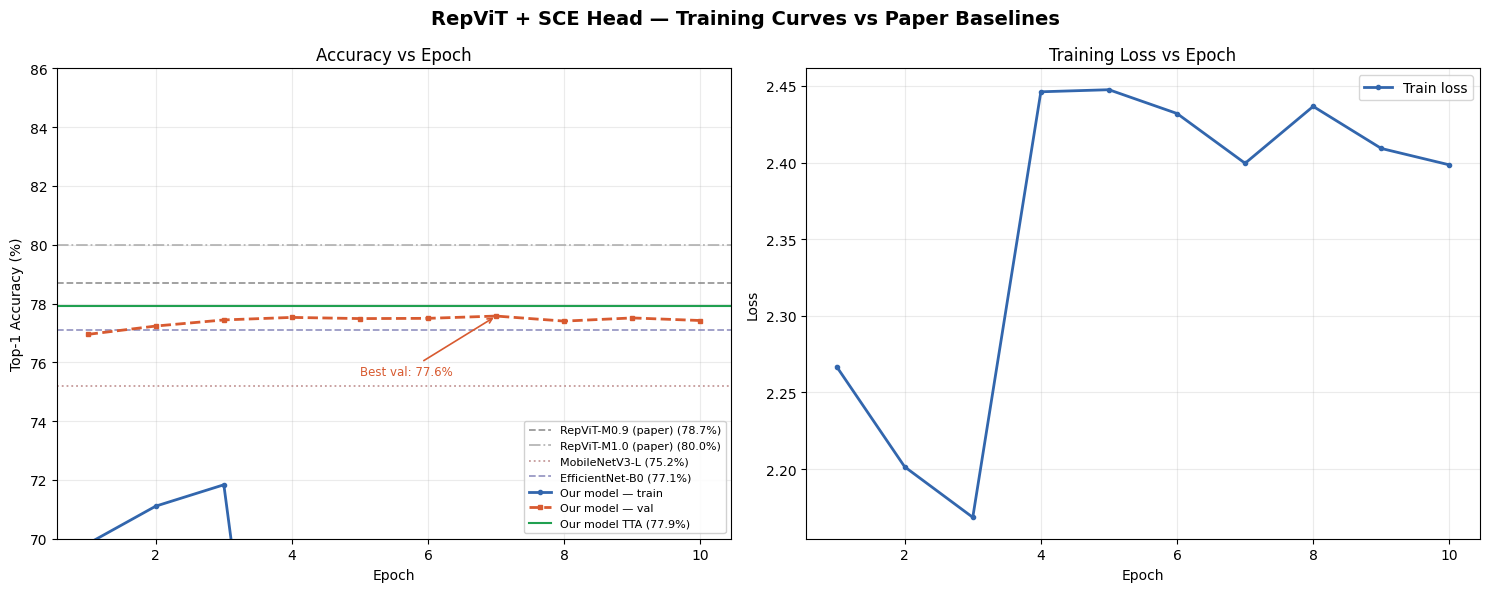

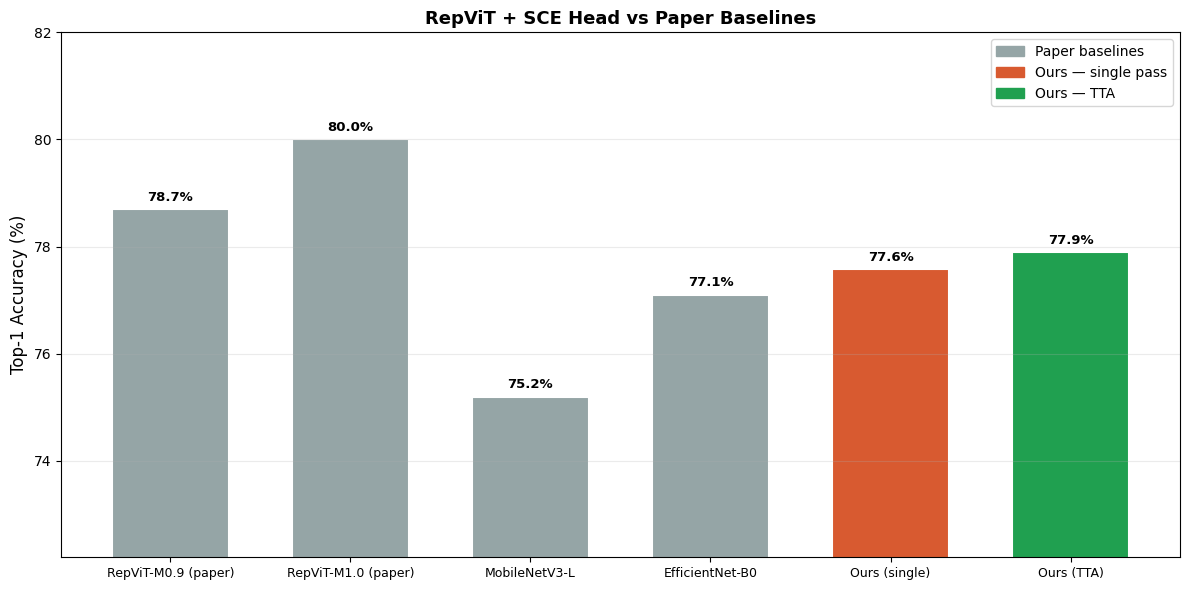


  Model                           Top-1 Acc vs Ours (TTA)
----------------------------------------------------------
  RepViT-M0.9 (paper)                 78.7%        -0.80%
  RepViT-M1.0 (paper)                 80.0%        -2.10%
  MobileNetV3-L                       75.2%        +2.70%
  EfficientNet-B0                     77.1%        +0.80%
----------------------------------------------------------
  Ours — SCE head (single pass)      77.57%              
  Ours — SCE head + TTA              77.90%    ← our best

Overfitting gap (last epoch): -24.05%
TTA gain over single pass   : +0.33%


In [21]:
# ============================================================
# CELL 12 — Visualisation
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

epochs_list = list(range(1, len(history["train_acc"]) + 1))

paper_baselines = {
    "RepViT-M0.9 (paper)"   : 78.7,
    "RepViT-M1.0 (paper)"   : 80.0,
    "MobileNetV3-L"          : 75.2,
    "EfficientNet-B0"        : 77.1,
}

MY_SINGLE = BEST_VAL * 100
MY_TTA    = tta_acc  * 100

# ── Figure 1: Training curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("RepViT + SCE Head — Training Curves vs Paper Baselines",
             fontsize=14, fontweight="bold")

ax = axes[0]
styles = [("--", "#888"), ("-.", "#aaa"), (":", "#b88"), ("--", "#88b")]
for (name, acc), (ls, col) in zip(paper_baselines.items(), styles):
    ax.axhline(acc, linestyle=ls, color=col, linewidth=1.3, alpha=0.85,
               label=f"{name} ({acc}%)")

ax.plot(epochs_list, history["train_acc"], color="#3266ad", linewidth=2,
        marker="o", markersize=3, label="Our model — train")
ax.plot(epochs_list, history["val_acc"],   color="#d85a30", linewidth=2,
        marker="s", markersize=3, linestyle="--", label="Our model — val")

ax.axhline(MY_TTA, linestyle="-", color="#20a050", linewidth=1.5,
           label=f"Our model TTA ({MY_TTA:.1f}%)")

ax.annotate(f"Best val: {MY_SINGLE:.1f}%",
            xy=(history["val_acc"].index(max(history["val_acc"])) + 1, MY_SINGLE),
            xytext=(5, MY_SINGLE - 2), fontsize=8.5, color="#d85a30",
            arrowprops=dict(arrowstyle="->", color="#d85a30", lw=1.2))

ax.set_xlabel("Epoch"); ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Accuracy vs Epoch")
ax.set_ylim(70, max(max(history["train_acc"]), 85) + 1)
ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(epochs_list, history["train_loss"], color="#3266ad", linewidth=2,
        marker="o", markersize=3, label="Train loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Loss vs Epoch")
ax.legend(); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: Bar comparison ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

all_models = list(paper_baselines.keys()) + ["Ours (single)", "Ours (TTA)"]
all_accs   = list(paper_baselines.values()) + [MY_SINGLE, MY_TTA]
colors     = ["#95a5a6"] * len(paper_baselines) + ["#d85a30", "#20a050"]

bars = ax.bar(all_models, all_accs, color=colors, edgecolor="white",
              linewidth=1.5, width=0.65)
for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{acc:.1f}%", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

ax.set_ylabel("Top-1 Accuracy (%)", fontsize=12)
ax.set_title("RepViT + SCE Head vs Paper Baselines", fontsize=13, fontweight="bold")
ax.set_ylim(min(all_accs) - 3, max(all_accs) + 2)
ax.tick_params(axis="x", labelsize=9)
ax.grid(axis="y", alpha=0.25)

legend_patches = [
    mpatches.Patch(color="#95a5a6", label="Paper baselines"),
    mpatches.Patch(color="#d85a30", label="Ours — single pass"),
    mpatches.Patch(color="#20a050", label="Ours — TTA"),
]
ax.legend(handles=legend_patches, fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 58)
print(f"  {'Model':<30} {'Top-1 Acc':>10} {'vs Ours (TTA)':>12}")
print("-" * 58)
for name, acc in paper_baselines.items():
    diff = MY_TTA - acc
    print(f"  {name:<30} {acc:>9.1f}%  {diff:>+11.2f}%")
print("-" * 58)
print(f"  {'Ours — SCE head (single pass)':<30} {MY_SINGLE:>9.2f}%  {'':>12}")
print(f"  {'Ours — SCE head + TTA':<30} {MY_TTA:>9.2f}%  {'← our best':>12}")
print("=" * 58)
gap = [t - v for t, v in zip(history["train_acc"], history["val_acc"])]
print(f"\nOverfitting gap (last epoch): {gap[-1]:.2f}%")
print(f"TTA gain over single pass   : +{(MY_TTA - MY_SINGLE):.2f}%")